# Audit des données Strava ingérées (V1)

Objectif : vérifier que l'ingestion (`docs/SPEC.md` V1) récupère bien ce qu'on croit récupérer, statistiques descriptives sur ce qui est réellement disponible, et définition des métriques Strava peu courantes trouvées dans les données réelles.

Toutes les définitions de métriques ci-dessous sont sourcées (doc Strava officielle ou, quand la formule exacte n'est pas publique, dit explicitement).

In [1]:
import json
import sqlite3
from pathlib import Path

import pandas as pd

DB_PATH = Path("..") / "data" / "sport_coaching.sqlite3"
conn = sqlite3.connect(DB_PATH)

activities = pd.read_sql_query("SELECT * FROM strava_activities", conn)
streams = pd.read_sql_query("SELECT * FROM strava_activity_streams", conn)

len(activities), len(streams)

(271, 2098)

## 1. Vue d'ensemble

In [2]:
print(f"{len(activities)} activités, {len(streams)} lignes de streams")
print(f"Période : {activities['start_date_local'].min()} → {activities['start_date_local'].max()}")

271 activités, 2098 lignes de streams
Période : 2024-03-27T15:04:46+00:00 → 2026-08-22T12:52:19+00:00


In [3]:
activities["sport_type"].value_counts()

sport_type
Run          135
Ride          50
Hike          32
Swim          32
Workout        7
Walk           6
TrailRun       5
AlpineSki      2
Snowboard      1
Rowing         1
Name: count, dtype: int64

Pas de type "Rugby" natif chez Strava (confirmé lors de l'implémentation, cf. `docs/METHODOLOGIE.md`) — cohérent avec l'absence attendue ici. Ces séances passeront par le module de saisie manuelle, pas par l'ingestion Strava.

## 2. Statistiques descriptives (métriques numériques du V1)

In [4]:
cols = ["distance_m", "moving_time_s", "elapsed_time_s", "total_elevation_gain_m"]
activities[cols].describe()

,distance_m,moving_time_s,elapsed_time_s,total_elevation_gain_m
count,271.000000,271.000000,271.000000,271.000000
mean,13297.228413,5631.826568,11036.095941,241.829889
std,14023.013488,7271.173603,24965.106084,471.839963
min,0.000000,132.000000,452.000000,0.000000
25%,5836.150000,2243.000000,2666.000000,11.200000
50%,9503.700000,3198.000000,3983.000000,34.000000
75%,15217.850000,5963.500000,10693.000000,217.550000
max,85106.000000,71765.000000,280631.000000,3038.000000


## 3. Couverture de la fréquence cardiaque

`average_heartrate`/`max_heartrate` sont calculés dans l'ingestion à partir du stream `heartrate`, pas d'un champ résumé (voir `strava_parser.compute_heartrate_stats`).

In [5]:
coverage = activities["average_heartrate"].notna().mean()
print(f"Couverture FC : {coverage:.0%} des activités ({activities['average_heartrate'].notna().sum()}/{len(activities)})")

activities.assign(has_hr=activities["average_heartrate"].notna()).groupby("sport_type")["has_hr"].agg(["sum", "count"]).rename(columns={"sum": "avec_FC", "count": "total"})

Couverture FC : 28% des activités (75/271)


,avec_FC,total
sport_type,,
AlpineSki,1,2
Hike,4,32
Ride,17,50
Rowing,1,1
Run,35,135
Snowboard,0,1
Swim,12,32
TrailRun,4,5
Walk,0,6


## 4. Couverture des streams (séries temporelles)

In [6]:
stream_coverage = streams.groupby("stream_type")["activity_id"].nunique().sort_values(ascending=False)
stream_coverage_pct = (stream_coverage / len(activities) * 100).round(1)
pd.DataFrame({"activités": stream_coverage, "% du total": stream_coverage_pct})

,activités,% du total
stream_type,,
velocity_smooth,259,95.6
moving,259,95.6
grade_smooth,259,95.6
time,259,95.6
altitude,257,94.8
distance,252,93.0
latlng,231,85.2
cadence,134,49.4
watts,96,35.4


`velocity_smooth`, `time`, `moving`, `grade_smooth` sont quasi systématiques (dérivables du GPS). `heartrate`, `watts`, `cadence`, `temp` dépendent du matériel réellement utilisé lors de la séance — logique, pas une anomalie d'ingestion.

## 5. Validation croisée : FC calculée (streams) vs FC résumée (Strava)

Découverte en auditant les données réelles : le JSON brut renvoyé par l'endpoint résumé (`/athlete/activities`) contient en fait `average_heartrate`/`max_heartrate` — alors que l'introspection de `stravalib.SummaryActivity.model_fields` (faite pendant le Plan Mode) ne les listait pas comme champs déclarés. Vraisemblablement des champs "extra" que la lib laisse passer sans les déclarer explicitement. Ce cross-check sert à la fois de validation de notre calcul et de leçon méthodologique : l'introspection d'une lib n'est pas équivalente à l'observation de données réelles.

In [7]:
def raw_field(raw_json, key):
    return json.loads(raw_json).get(key)

activities["raw_average_heartrate"] = activities["raw_json"].apply(lambda r: raw_field(r, "average_heartrate"))
activities["raw_max_heartrate"] = activities["raw_json"].apply(lambda r: raw_field(r, "max_heartrate"))

both = activities.dropna(subset=["average_heartrate", "raw_average_heartrate"]).copy()
both["delta_avg_hr"] = (both["average_heartrate"] - both["raw_average_heartrate"]).abs()

print(f"{len(both)} activités où les deux sources existent")
both["delta_avg_hr"].describe()

75 activités où les deux sources existent


count    75.000000
mean      1.303991
std       2.820209
min       0.002440
25%       0.108688
50%       0.263128
75%       1.111031
max      18.323496
Name: delta_avg_hr, dtype: float64

In [8]:
both.sort_values("delta_avg_hr", ascending=False)[["id", "name", "average_heartrate", "raw_average_heartrate", "delta_avg_hr"]].head(10)

,id,name,average_heartrate,raw_average_heartrate,delta_avg_hr
212,18386109176,Sortie vélo dans l'après-midi,90.976504,109.3,18.323496
253,19506199615,Evening Ride,124.053832,134.4,10.346168
195,17892071808,Ski alpin le midi,97.088790,106.7,9.611210
220,18468344855,Course à pied en soirée,145.639623,152.9,7.260377
221,18572241735,Sortie vélo de nuit,117.263489,123.1,5.836511
217,18427615244,Sortie vélo le matin,123.580216,127.5,3.919784
214,18400994378,Randonnée dans l'après-midi,104.489367,107.9,3.410633
240,19096576941,Pic de la belle étoile ⛰️,118.635500,115.3,3.335500
196,17902281201,Col d'Izoard,109.447571,112.7,3.252429
215,18400994700,Randonnée le midi,102.969015,105.6,2.630985


## 6. Audit de complétude : champs Strava réels non capturés en colonnes dédiées

Comparaison entre l'ensemble des clés présentes dans `raw_json` (donc réellement renvoyées par Strava pour ce compte) et les colonnes de `strava_activities`. Tout ce qui apparaît ici est disponible mais actuellement seulement accessible via `raw_json`, pas en colonne directement requêtable.

In [9]:
raw_keys = set()
for raw in activities["raw_json"]:
    raw_keys |= set(json.loads(raw).keys())

db_columns = set(activities.columns) - {"raw_average_heartrate", "raw_max_heartrate"}
not_in_schema = sorted(raw_keys - db_columns)
not_in_schema

['achievement_count',
 'athlete',
 'athlete_count',
 'average_speed',
 'average_watts',
 'comment_count',
 'commute',
 'device_name',
 'device_watts',
 'distance',
 'elapsed_time',
 'elev_high',
 'elev_low',
 'end_latlng',
 'external_id',
 'flagged',
 'from_accepted_tag',
 'gear_id',
 'has_heartrate',
 'has_kudoed',
 'hide_from_home',
 'kilojoules',
 'kudos_count',
 'location_city',
 'location_country',
 'location_state',
 'manual',
 'map',
 'max_speed',
 'max_watts',
 'moving_time',
 'photo_count',
 'pr_count',
 'private',
 'start_latlng',
 'total_elevation_gain',
 'total_photo_count',
 'trainer',
 'upload_id',
 'upload_id_str',
 'utc_offset',
 'visibility',
 'weighted_average_watts',
 'workout_type']

## 7. Définition des métriques peu courantes trouvées

| Champ | Définition | Source |
|---|---|---|
| `suffer_score` | Nom API de "Relative Effort" (a remplacé l'ancien "Suffer Score" en 2018). Charge cardiovasculaire basée sur le modèle TRIMP de Bannister : le temps passé dans chaque zone de FC (déterminée via la FC max de l'athlète) est pondéré par un coefficient croissant avec l'intensité de la zone. **Formule exacte propriétaire, non publiée par Strava.** Nécessite des données de FC. | [Strava — Quantifying Effort through Heart Rate Data](https://medium.com/strava-engineering/quantifying-effort-through-heart-rate-data-e6a0e3dd6a52) |
| `weighted_average_watts` | Puissance pondérée : lissage des données de puissance brute, mise à la puissance 4, moyenne, puis racine 4ème — Strava calcule le xPower de Skiba, très proche du "Normalized Power" (TrainingPeaks). Ignore les valeurs nulles (contrairement à `average_watts` qui les inclut). | [Strava Help — Power](https://support.strava.com/hc/en-us/articles/216918457-Power) |
| `kilojoules` | Travail total produit, dérivé de la puissance (nécessite un capteur de puissance). | Champ API standard, calcul physique direct (puissance × temps) |
| `average_cadence` | Cadence moyenne (tr/min vélo, pas/min course) sur toute l'activité. | Champ API standard |
| `device_watts` | Booléen : `true` si la puissance vient d'un vrai capteur de puissance, `false`/`null` si estimée. | Champ API standard |
| `has_heartrate` | Booléen : capteur FC utilisé ou non pour cette activité. | Champ API standard |
| `achievement_count`, `pr_count`, `kudos_count`, `comment_count`, `athlete_count` | Métriques sociales/gamification Strava (records personnels, kudos, commentaires) — pas des métriques physiologiques, hors périmètre du projet. | Champs API standard |
| `visibility`, `from_accepted_tag`, `hide_from_home` | Paramètres de confidentialité/affichage propres à l'app Strava — hors périmètre du projet. | Champs API standard |

## 8. Conclusions et recommandations pour `docs/SPEC.md`

1. **`average_heartrate`/`max_heartrate`/`suffer_score`/`average_cadence` sont réellement disponibles sur l'endpoint résumé** (via `raw_json`), contrairement à l'hypothèse posée en Plan Mode (basée sur l'introspection de `stravalib.SummaryActivity.model_fields`, incomplète face aux champs "extra" réellement renvoyés). À considérer pour une v2 du schéma : les exposer en colonnes dédiées plutôt que seulement dans `raw_json`.
2. Le calcul `average_heartrate` à partir du stream `heartrate` reste néanmoins justifié : il fonctionne même quand `raw_json` ne le fournit pas, et la section 5 permet de vérifier s'il diverge significativement de la valeur Strava — à réexaminer si `delta_avg_hr` s'avère non négligeable.
3. `suffer_score` (Relative Effort) est le candidat le plus pertinent à ajouter ensuite : c'est déjà une charge d'entraînement calculée par Strava avec une méthode proche de ce que le module de charge du projet doit produire (`docs/SPEC.md` §3) — utile comme point de comparaison/sanity-check pour notre propre formule, pas comme remplacement (formule propriétaire non reproductible).

## 9. Dashboard d'analyse d'activité (façon app Strava)

Fonction réutilisable (`sport_coaching.metrics.activity_report.plot_activity_dashboard`), pas seulement du code de notebook — reproduit les stats globales + graphiques temporels que Strava affiche pour une activité donnée. Palette et specs de traits : skill dataviz du projet (couleurs catégorielles fixes, un axe par graphique, pas de double axe).

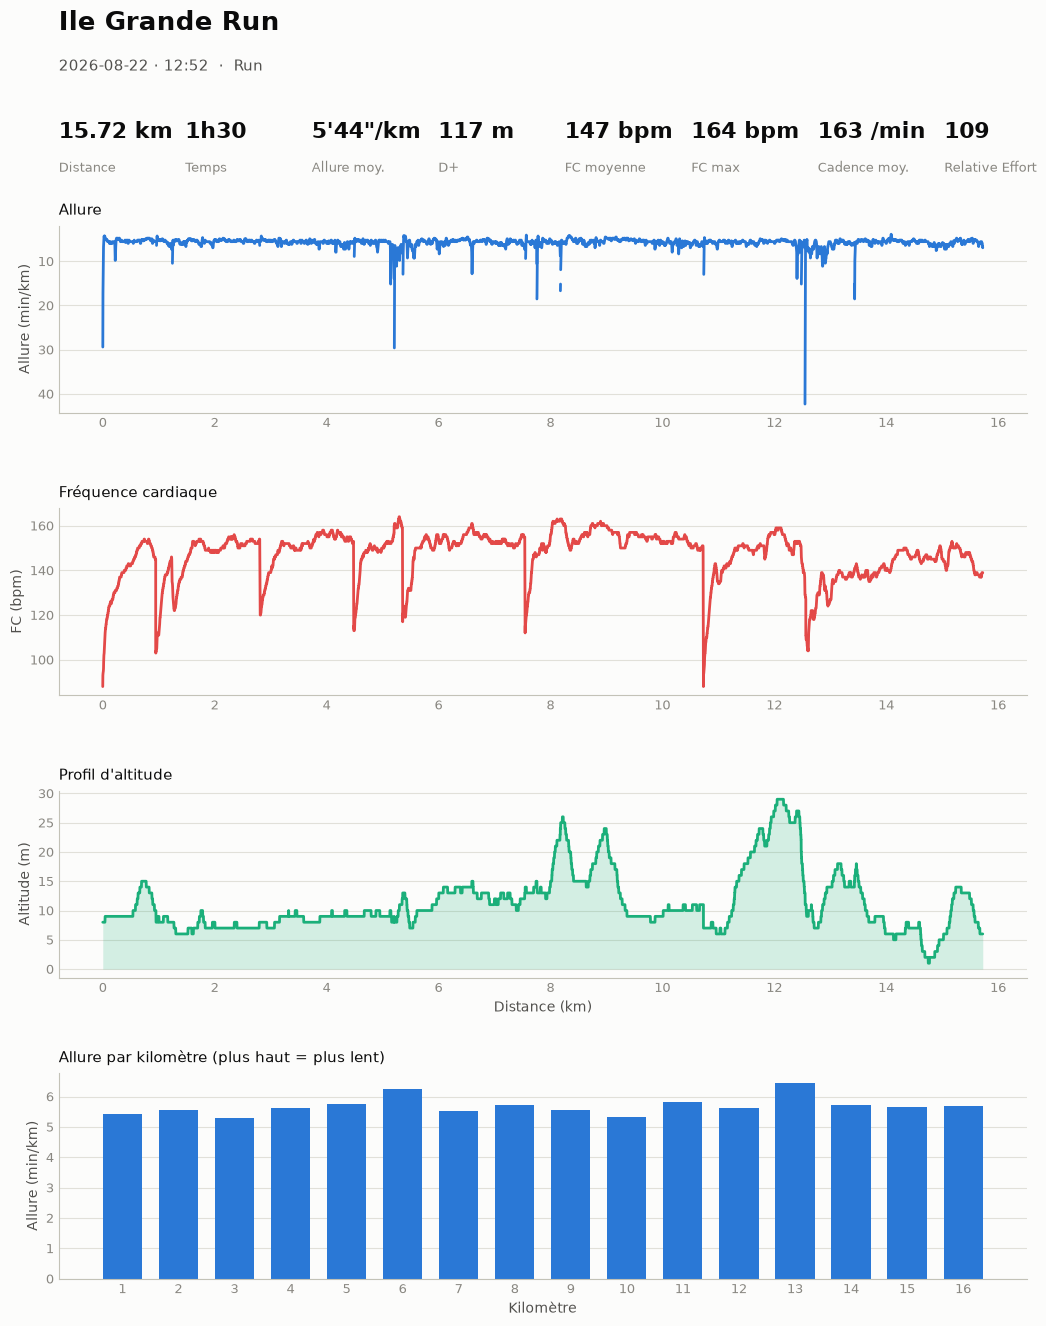

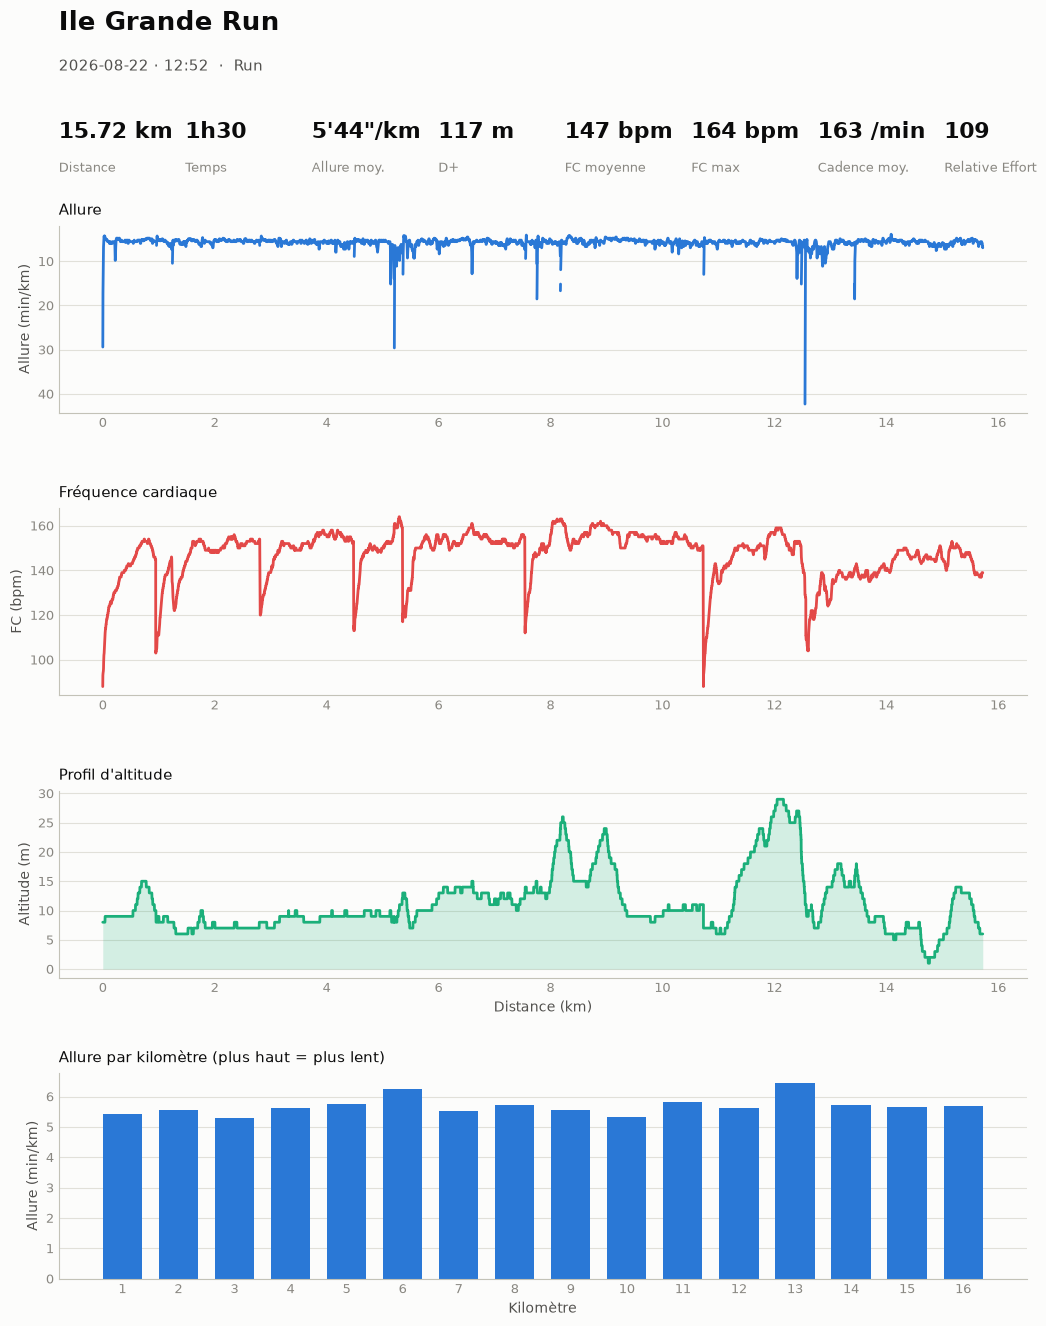

In [10]:
from sport_coaching.metrics.activity_report import plot_activity_dashboard

# Une sortie longue avec streams complets (FC, allure, altitude) pour la démo.
DEMO_ACTIVITY_ID = 19860695223  # "Ile Grande Run", 15.7 km

fig = plot_activity_dashboard(conn, DEMO_ACTIVITY_ID)
fig

Pour analyser une autre activité, changer `DEMO_ACTIVITY_ID` — par exemple avec l'ID d'une sortie plus courte ou sans FC, pour voir le comportement de repli (message explicite plutôt qu'un graphique vide silencieux).